# 02 - Matrices and Transformations

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Make sure we get outputs from a probabilitistic model each time (for reproducibility)
np.random.seed(1515)

## What is a Matrix?

A **matrix** is a grid of numbers, arranged in rows and columns. You've already met several without necessarily calling them that: the **Rotation Matrix** $R$ and **Translation Matrix** $t$ from `perception_primer/03-intrinsics-extrinsics.ipynb`, the **Intrinsic Matrix** $K$ from that same notebook, and the **Essential Matrix** from `perception_primer/05-objects-in-motion.ipynb`'s Visual Odometry section are all matrices.

Where `01-vectors.ipynb` was about a single point or direction, a matrix is about **transforming** vectors - rotating them, scaling them, or otherwise remapping them into new vectors.

### Matrices as Transformations: the Matrix-Vector Product

A **matrix-vector product** takes a matrix $M$ and a vector $v$ and produces a new vector $Mv$ - this is what a **Linear Transformation** actually is. For a 2D rotation by angle $\theta$, the matrix looks like this:

$$ R(\theta) = \begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix} $$

This is the same *shape* of object as the rotation matrices `cv2.Rodrigues` and `cv2.recoverPose` were producing and consuming in `perception_primer/05` - just written out by hand here instead of built by OpenCV, so you can see exactly what's inside it.

In [2]:
def rotation_matrix_2d(theta_rad):
    return np.array([
        [np.cos(theta_rad), -np.sin(theta_rad)],
        [np.sin(theta_rad),  np.cos(theta_rad)]
    ])

point = np.array([1.0, 0.0])         # a point sitting on the x-axis
theta = np.radians(90)               # rotate it 90 degrees counterclockwise
R = rotation_matrix_2d(theta)

rotated_point = R @ point   # the matrix-vector product
print(f"R:\n{R.round(3)}")
print(f"\noriginal point:  {point}")
print(f"rotated point:   {rotated_point.round(3)}")

R:
[[ 0. -1.]
 [ 1.  0.]]

original point:  [1. 0.]
rotated point:   [0. 1.]


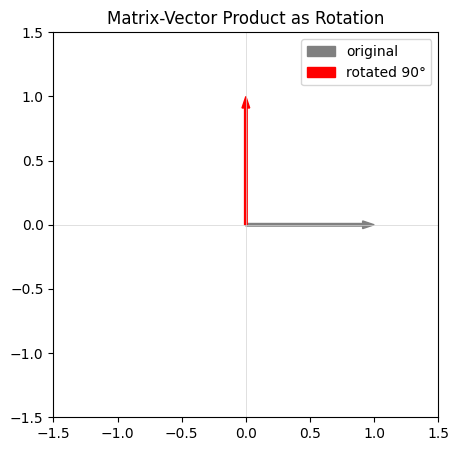

In [3]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.arrow(0, 0, *point, color='gray', width=0.02, length_includes_head=True, label='original')
ax.arrow(0, 0, *rotated_point, color='red', width=0.02, length_includes_head=True, label='rotated 90°')
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.axhline(0, color='lightgray', linewidth=0.5)
ax.axvline(0, color='lightgray', linewidth=0.5)
ax.set_aspect('equal')
ax.set_title('Matrix-Vector Product as Rotation')
ax.legend()
plt.show()

A point on the x-axis rotates to sit on the y-axis after a 90-degree rotation - exactly what we'd expect, and exactly the operation `cv2.Rodrigues`/`cv2.recoverPose` were doing under the hood in `perception_primer/05`, just for 3D rotations instead of 2D.

### Matrix Multiplication: Composing Transformations

**Matrix multiplication** combines two matrices into a single matrix that represents applying both of their transformations in sequence. If $R_1$ rotates by $\theta_1$ and $R_2$ rotates by $\theta_2$, then $R_2 R_1$ (apply $R_1$ first, then $R_2$) should be the same as rotating by $\theta_1 + \theta_2$ all at once.

This is exactly what's packed inside the **Extrinsic Matrix** $M = [R \mid t]$ from `perception_primer/03-intrinsics-extrinsics.ipynb`: a rotation and a translation, composed into one transformation that takes a world point all the way to camera coordinates in a single matrix-vector product.

In [4]:
theta1 = np.radians(30)
theta2 = np.radians(60)

R1 = rotation_matrix_2d(theta1)
R2 = rotation_matrix_2d(theta2)
R_composed = R2 @ R1                        # apply R1, then R2
R_direct = rotation_matrix_2d(theta1 + theta2)   # rotate by the sum directly

print(f"R2 @ R1:\n{R_composed.round(3)}")
print(f"\nR(theta1 + theta2) directly:\n{R_direct.round(3)}")
print(f"\nSame matrix? {np.allclose(R_composed, R_direct)}")

R2 @ R1:
[[ 0. -1.]
 [ 1.  0.]]

R(theta1 + theta2) directly:
[[ 0. -1.]
 [ 1.  0.]]

Same matrix? True


Now let's compose a rotation with a translation - a small rigid transform, exactly the $[R \mid t]$ shape the Extrinsic Matrix uses, just kept as separate steps here so each one stays visible.

In [5]:
t = np.array([2.0, 0.0])   # shift everything 2 units in x, after rotating

world_point = np.array([1.0, 0.0])
rotated = R @ world_point          # apply rotation first (R from the 90-degree example above)
transformed = rotated + t          # then apply the translation

print(f"world point:               {world_point}")
print(f"after rotation:             {rotated.round(3)}")
print(f"after rotation + translation: {transformed.round(3)}")

world point:               [1. 0.]
after rotation:             [0. 1.]
after rotation + translation: [2. 1.]


### Identity Matrix and Transpose

The **Identity Matrix** $I$ leaves any vector unchanged when applied to it - it's linear algebra's version of multiplying by 1. The **Transpose** of a matrix, $M^T$, swaps its rows and columns.

Rotation matrices have a convenient special property worth knowing by name: for a rotation matrix specifically, the transpose *is* the inverse ($R^T = R^{-1}$, so $R^T R = I$). This is why you'll sometimes see `R.T` used in place of a full matrix inverse when undoing a rotation in vision code - it's not a shortcut or an approximation, it's mathematically exact for this one specific kind of matrix.

In [6]:
I = np.eye(2)
print(f"Identity matrix:\n{I}")
print(f"I @ point == point? {np.allclose(I @ point, point)}")

print(f"\nR:\n{R.round(3)}")
print(f"R.T (transpose):\n{R.T.round(3)}")
print(f"R.T @ R:\n{(R.T @ R).round(3)}")
print(f"R.T @ R == I? {np.allclose(R.T @ R, I)}")

Identity matrix:
[[1. 0.]
 [0. 1.]]
I @ point == point? True

R:
[[ 0. -1.]
 [ 1.  0.]]
R.T (transpose):
[[ 0.  1.]
 [-1.  0.]]
R.T @ R:
[[1. 0.]
 [0. 1.]]
R.T @ R == I? True


### Invertibility and the Determinant

A matrix's **inverse** $M^{-1}$ is the matrix that "undoes" its transformation: $M^{-1}(Mv) = v$. Not every matrix has one - a matrix that collapses two dimensions down onto one (like projecting everything onto a single line) throws away information permanently, and there's no way to reconstruct the original vector from the result alone.

The **Determinant** is a single number computed from a matrix that tells you whether an inverse exists: a determinant of exactly zero means the matrix is **not invertible**. A rotation matrix always has determinant 1 (it preserves lengths and areas, it just reorients them).

In [7]:
# Rotation matrices are always invertible
R_inv = np.linalg.inv(R)
print(f"R @ R_inv == I? {np.allclose(R @ R_inv, I)}")
print(f"det(R) = {np.linalg.det(R):.3f}")

# A matrix that projects everything onto the x-axis - it throws away the y-component,
# so it can't be undone: two different inputs can produce the identical output.
project_onto_x = np.array([
    [1, 0],
    [0, 0]
])
print(f"\ndet(project_onto_x) = {np.linalg.det(project_onto_x):.3f}")

point_a = np.array([3.0, 5.0])
point_b = np.array([3.0, -100.0])
print(f"project_onto_x @ point_a = {project_onto_x @ point_a}")
print(f"project_onto_x @ point_b = {project_onto_x @ point_b}")
print("Same output, different inputs - no inverse could ever recover which one it was.")

R @ R_inv == I? True
det(R) = 1.000

det(project_onto_x) = 0.000
project_onto_x @ point_a = [3. 0.]
project_onto_x @ point_b = [3. 0.]
Same output, different inputs - no inverse could ever recover which one it was.


### Where This Is Going: Matrices in Neural Networks

Recall the single neuron formula from `cv_primer/03-neural-networks.ipynb`: $f(b + \sum_{i=1}^{n} x_i w_i)$ - a weighted sum of inputs, plus a bias, passed through an activation function. That sum, $\sum_i x_i w_i$, is a **dot product** (`01-vectors.ipynb`) between the input vector and that one neuron's weight vector.

A full layer of neurons stacks many of those weight vectors into rows of a single **weight matrix** $W$, so the *entire layer's* output becomes one matrix-vector product: $f(Wx + b)$, exactly the operation this notebook has been practicing. "Training a neural network" is largely the process of adjusting the numbers inside $W$ so that this matrix-vector product produces useful outputs - which is exactly where the upcoming Deep Learning module picks up.

## Try It Yourself

1. Build a 2D **scaling matrix** that doubles the x-component of a vector and leaves y unchanged: $\begin{pmatrix} 2 & 0 \\ 0 & 1 \end{pmatrix}$.
2. Using `R` (the 90-degree rotation matrix from earlier in this notebook) and your new scaling matrix `S`, compute both `S @ R @ point` and `R @ S @ point` for `point = np.array([1.0, 0.0])`.
3. Compare the two results. They should be different - **matrix multiplication is not commutative**, meaning order matters. Write one sentence connecting this to a real robot: why would "rotate, then translate" and "translate, then rotate" send a robot to two different final positions on the field?

In [8]:
# TODO: 1. build the scaling matrix S

# TODO: 2. compute S @ R @ point and R @ S @ point

# TODO: 3. compare the two results - are they the same vector?


## Resources

- [3Blue1Brown: Essence of Linear Algebra - Linear Transformations & Matrix Multiplication](https://www.3blue1brown.com/topics/linear-algebra) - the visual intuition this notebook builds on (video series).
- [NumPy: Linear Algebra (`numpy.linalg`)](https://numpy.org/doc/stable/reference/routines.linalg.html) - `inv`, `det`, and related functions used above (reference).
- [OpenCV: `Rodrigues`](https://docs.opencv.org/4.x/d9/d0c/group__calib3d.html) - the function that builds a full 3D rotation matrix from an axis-angle vector, used throughout `perception_primer/05-objects-in-motion.ipynb` (reference).